In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier

df = pd.read_csv("heart.csv")

# Extract features and target
X = df[["restecg", "chol"]]
y = df["target"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

rf = RandomForestClassifier(random_state=0)
ab = AdaBoostClassifier(random_state=0, algorithm="SAMME")

rf.fit(X_train, y_train)
ab.fit(X_train, y_train)

rf_train_acc = rf.score(X_train, y_train)
rf_test_acc = rf.score(X_test, y_test)
ab_train_acc = ab.score(X_train, y_train)
ab_test_acc = ab.score(X_test, y_test)

print(f"Random Forest -> Train Accuracy: {rf_train_acc*100:.2f}%, Test Accuracy: {rf_test_acc*100:.2f}%")
print(f"AdaBoost -> Train Accuracy: {ab_train_acc*100:.2f}%, Test Accuracy: {ab_test_acc*100:.2f}%")


Random Forest -> Train Accuracy: 88.41%, Test Accuracy: 83.90%
AdaBoost -> Train Accuracy: 61.71%, Test Accuracy: 55.61%



Voting Ensemble -> Train Accuracy: 88.17%, Test Accuracy: 84.39%


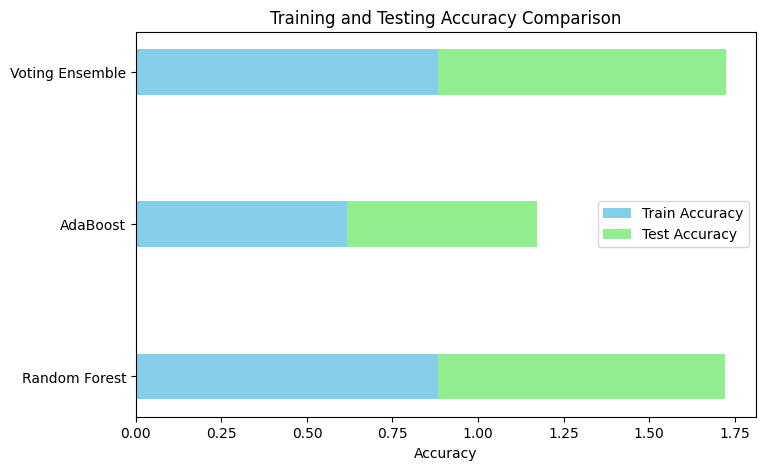

In [4]:
voting = VotingClassifier(estimators=[('rf', rf), ('ab', ab)], voting='soft')
voting.fit(X_train, y_train)

voting_train_acc = voting.score(X_train, y_train)
voting_test_acc = voting.score(X_test, y_test)
print(f"\nVoting Ensemble -> Train Accuracy: {voting_train_acc*100:.2f}%, Test Accuracy: {voting_test_acc*100:.2f}%")

models = ['Random Forest', 'AdaBoost', 'Voting Ensemble']
train_acc = [rf_train_acc, ab_train_acc, voting_train_acc]
test_acc = [rf_test_acc, ab_test_acc, voting_test_acc]

plt.figure(figsize=(8,5))
plt.barh(models, train_acc, height=0.3, label='Train Accuracy', color='skyblue', left=0)
plt.barh(models, test_acc, height=0.3, label='Test Accuracy', color='lightgreen', left=train_acc)
plt.xlabel("Accuracy")
plt.title("Training and Testing Accuracy Comparison")
plt.legend()
plt.show()